# Convolutional Autoencoder for Mass Spectra

This notebook builds a Convolutional Autoencoder (CAE) to learn a compressed representation of mass spectra data and reduce noise. CAEs are well-suited for this task as they can learn local patterns in the spectra. We will also apply a log transformation to the data to handle the wide dynamic range of peak intensities.


## 1. Setup and Data Loading

First, we import the necessary libraries.


In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
import matplotlib.pyplot as plt


2026-01-18 12:31:55.106750: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


No supported GPU was found.


Load the dataset from the Parquet file.


In [2]:
file_path = 'cda_qm_spectra_train_pre2008277_lvl1.parquet'
try:
    spectra_df = pd.read_parquet(file_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")


Dataset loaded successfully.


## 2. Data Preprocessing

We will preprocess the data by:
1.  **Log Transformation:** To handle the wide range of intensity values.
2.  **Normalization:** To scale the data to a [0, 1] range.


In [3]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Separate metadata from spectra
metadata_cols = ['id', 'precursor_mz', 'precursor_charge', 'retention_time', 'scan_number']
# Keep 'class' for the labels
spectra_cols = [col for col in spectra_df.columns if col not in metadata_cols and col != 'class']

# Convert spectra columns to numeric, coercing errors
for col in spectra_cols:
    spectra_df[col] = pd.to_numeric(spectra_df[col], errors='coerce')

# Fill any NaN values
spectra_df[spectra_cols] = spectra_df[spectra_cols].fillna(0)

# Extract the spectra data
spectra_data = spectra_df[spectra_cols].values

# --- Preprocess Class Labels ---
# Extract class labels
y_labels = spectra_df['class'].values

# Integer encode
label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(y_labels)

# One-hot encode
onehot_encoder = OneHotEncoder(sparse_output=False)
integer_encoded = integer_encoded.reshape(len(integer_encoded), 1)
y_train = onehot_encoder.fit_transform(integer_encoded)
n_classes = y_train.shape[1]
print(f"Found {n_classes} unique classes.")
# --- End of Label Preprocessing ---


def preprocess_spectra(spectra):
    # Log transform
    log_spectra = np.log1p(spectra)
    # Normalize
    min_vals = log_spectra.min(axis=1, keepdims=True)
    max_vals = log_spectra.max(axis=1, keepdims=True)
    range_vals = max_vals - min_vals
    range_vals[range_vals == 0] = 1
    return (log_spectra - min_vals) / range_vals

X_train = preprocess_spectra(spectra_data)

print("Training data preprocessed.")
print("Shape of the training data:", X_train.shape)
print("Shape of the training labels:", y_train.shape)

Found 14 unique classes.
Training data preprocessed.
Shape of the training data: (19817, 5)
Shape of the training labels: (19817, 14)


## Load and Preprocess Validation Data


In [4]:
validation_file_path = 'cda_qm_spectra_pre2008277_lvl1.parquet'
try:
    validation_spectra_df = pd.read_parquet(validation_file_path)
    print("Validation dataset loaded successfully.")
except FileNotFoundError:
    print(f"Error: The file was not found at {validation_file_path}")

if 'validation_spectra_df' in locals():
    for col in spectra_cols:
        validation_spectra_df[col] = pd.to_numeric(validation_spectra_df[col], errors='coerce')
    validation_spectra_df[spectra_cols] = validation_spectra_df[spectra_cols].fillna(0)
    
    # Preprocess validation spectra
    validation_spectra_data = validation_spectra_df[spectra_cols].values
    X_val = preprocess_spectra(validation_spectra_data)
    
    # Preprocess validation labels
    y_val_labels = validation_spectra_df['class'].values
    integer_encoded_val = label_encoder.transform(y_val_labels) # Use the same encoder
    integer_encoded_val = integer_encoded_val.reshape(len(integer_encoded_val), 1)
    y_val = onehot_encoder.transform(integer_encoded_val) # Use the same encoder

    print("Validation data preprocessed.")
    print("Shape of the validation data:", X_val.shape)
    print("Shape of the validation labels:", y_val.shape)

Validation dataset loaded successfully.


/var/folders/c0/h7rcgjdd7p35pczt_n1jjp8h0000gn/T/ipykernel_7497/3787916923.py:37: RuntimeWarning: invalid value encountered in log1p
  log_spectra = np.log1p(spectra)


ValueError: y contains previously unseen labels: -1000

## 3. Reshape Data for Convolutional Layers

We need to reshape the data to be compatible with Keras's `Conv1D` layers, which expect a 3D input (`batch_size`, `steps`, `channels`).


In [ ]:
X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)

print("Reshaped training data shape:", X_train.shape)
print("Reshaped validation data shape:", X_val.shape)


Reshaped training data shape: (19817, 6, 1)
Reshaped validation data shape: (774953, 6, 1)


## 4. Build the Convolutional Classifier

In [ ]:
from tensorflow.keras.layers import Flatten, Dense

input_shape = (X_train.shape[1], 1)

# Feature Extractor (Encoder)
input_layer = Input(shape=input_shape)
x = Conv1D(32, 3, activation="relu", padding="same")(input_layer)
x = MaxPooling1D(2, padding="same")(x)
x = Conv1D(16, 3, activation="relu", padding="same")(x)
encoded = MaxPooling1D(2, padding="same")(x)

# Classification Head
x = Flatten()(encoded)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
# Output layer with softmax activation for multi-class classification
output_layer = Dense(n_classes, activation='softmax')(x)

classifier = Model(input_layer, output_layer)
classifier.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
classifier.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 6, 1)]            0         
                                                                 
 conv1d_8 (Conv1D)           (None, 6, 32)             128       
                                                                 
 max_pooling1d_4 (MaxPooling  (None, 3, 32)            0         
 1D)                                                             
                                                                 
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 6, 1)]            0         
                                                                 
 conv1d_8 (Conv1D)           (None, 6, 32)             128       
                                                           

## 5. Model Training


In [ ]:
history = classifier.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(X_val, y_val)
)

Epoch 1/50
78/78 [==============================] - 7s 80ms/step - loss: 0.0555 - val_loss: nan
Epoch 2/50
78/78 [==============================] - 7s 80ms/step - loss: 0.0555 - val_loss: nan
Epoch 2/50
78/78 [==============================] - 6s 73ms/step - loss: 0.0010 - val_loss: nan
Epoch 3/50
78/78 [==============================] - 6s 73ms/step - loss: 0.0010 - val_loss: nan
Epoch 3/50
78/78 [==============================] - 5s 70ms/step - loss: 4.0254e-04 - val_loss: nan
Epoch 4/50
78/78 [==============================] - 5s 70ms/step - loss: 4.0254e-04 - val_loss: nan
Epoch 4/50
78/78 [==============================] - 5s 68ms/step - loss: 3.1662e-04 - val_loss: nan
Epoch 5/50
78/78 [==============================] - 5s 68ms/step - loss: 3.1662e-04 - val_loss: nan
Epoch 5/50
78/78 [==============================] - 5s 68ms/step - loss: 2.7055e-04 - val_loss: nan
Epoch 6/50
78/78 [==============================] - 5s 68ms/step - loss: 2.7055e-04 - val_loss: nan
Epoch 6/50
78/78

## 6. Model Evaluation


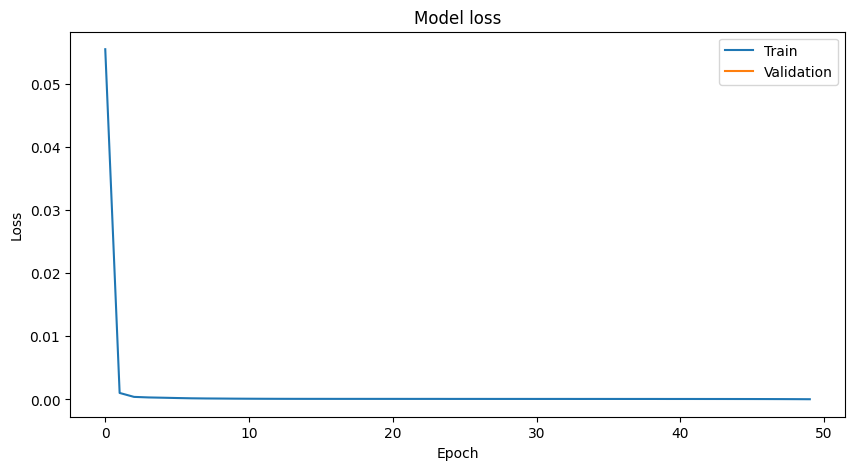

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()